In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
files = {
    "df_inj1": "../data/PNR/raw/PNR-1z_injection_rates.txt",
    "df_inj2": "../data/PNR/raw/PNR-2_injection_rates.txt",
    "df_cat1": "../data/PNR/raw/PNR-1z_microseismicity_catalogue.txt",
    "df_cat2": "../data/PNR/raw/PNR-2_microseismicity_catalogue.txt",
}

_read = lambda p: pd.read_csv(p, sep=r"\s+", skiprows=[0, 2], header=0)
for name, path in files.items():
    globals()[name] = _read(path)

In [2]:
def add_datetime_column(df, out_col='datetime', set_index=False,delete_original=False):
    candidates = {
        'year': ('year', 'Year', 'YEAR'),
        'month': ('month', 'Month', 'MONTH'),
        'day': ('day', 'Day', 'DAY', 'Day '),
        'hour': ('hr', 'hour', 'Hour', 'HR'),
        'minute': ('min', 'minute', 'Minute', 'MIN'),
        'second': ('sec', 'second', 'Second', 'SEC')
    }

    def _pick(col_names):
        for c in col_names:
            if c in df.columns:
                return c
        raise KeyError(f"None of {col_names} found in dataframe columns")

    picked = {k: _pick(v) for k, v in candidates.items()}

    # prepare subset and rename to pandas-expected names
    subset = df[[picked['year'], picked['month'], picked['day'],
                 picked['hour'], picked['minute'], picked['second']]].rename(
        columns={
            picked['year']: 'year',
            picked['month']: 'month',
            picked['day']: 'day',
            picked['hour']: 'hour',
            picked['minute']: 'minute',
            picked['second']: 'second'
        }
    )
    df[out_col] = pd.to_datetime(subset)
    if set_index:
        df.set_index(out_col, inplace=True)
    if delete_original:
        df.drop(columns=list(picked.values()), inplace=True)
    return df


In [3]:
for name in ("df_inj1", "df_inj2", "df_cat1", "df_cat2"):
    globals()[name] = add_datetime_column(globals()[name], out_col="datetime", set_index=True, delete_original=True)

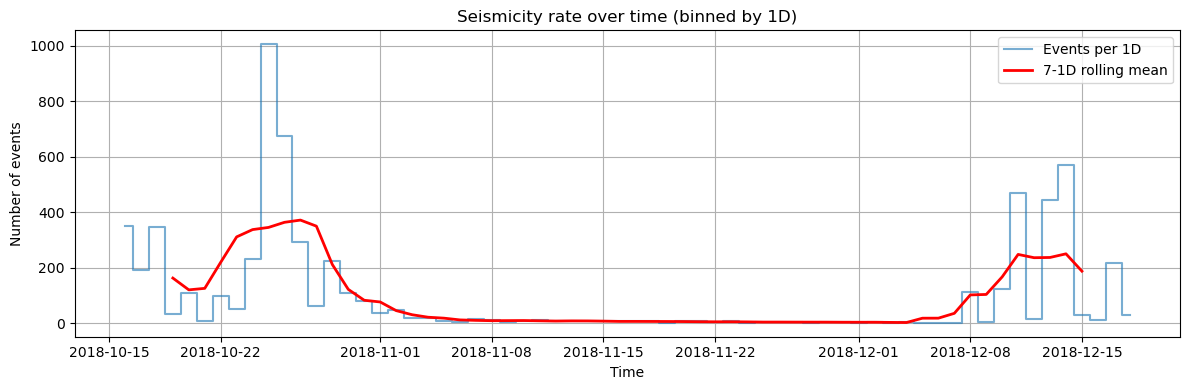

In [6]:
# Try to specify common CJK fonts to avoid missing-glyph warnings (matplotlib picks the first available)
plt.figure(figsize=(12,4))
freq = '1D'  # 1 day
window = 7  # 7 periods
df_cat1_filtered = df_cat1[df_cat1['Mag'] >= -1.5]
event_counts = df_cat1_filtered.resample(freq).size()
smoothed = event_counts.rolling(window=window, center=True).mean()
plt.plot(event_counts.index, event_counts, drawstyle='steps-mid', alpha=0.6, label=f'Events per {freq}')
plt.plot(smoothed.index, smoothed, color='red', lw=2, label=f'{window}-{freq} rolling mean')
plt.xlabel('Time')
plt.ylabel('Number of events')
plt.title(f'Seismicity rate over time (binned by {freq})')
plt.legend()
plt.grid(True)
plt.tight_layout()


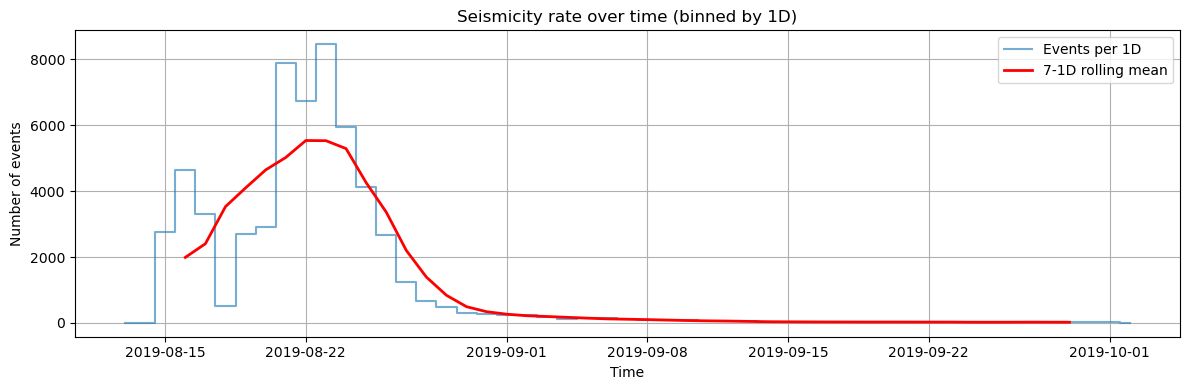

In [7]:
# Try to specify common CJK fonts to avoid missing-glyph warnings (matplotlib picks the first available)
plt.figure(figsize=(12,4))
freq = '1D'  # 1 day
window = 7  # 7 periods
event_counts = df_cat2.resample(freq).size()
smoothed = event_counts.rolling(window=window, center=True).mean()
plt.plot(event_counts.index, event_counts, drawstyle='steps-mid', alpha=0.6, label=f'Events per {freq}')
plt.plot(smoothed.index, smoothed, color='red', lw=2, label=f'{window}-{freq} rolling mean')
plt.xlabel('Time')
plt.ylabel('Number of events')
plt.title(f'Seismicity rate over time (binned by {freq})')
plt.legend()
plt.grid(True)
plt.tight_layout()


<Axes: >

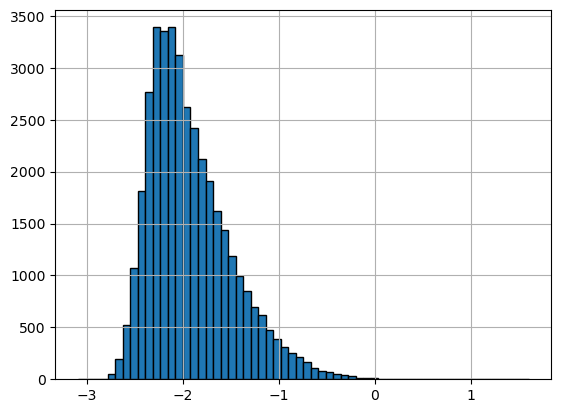

In [8]:
df_cat1['Mag'].hist(bins=60, edgecolor='black')

In [9]:
len(df_cat2[df_cat2['Mag']>-2])

54257

In [14]:
inj1_sch = pd.read_csv("../data/PNR/raw/pnr1z_inj_sch.csv")
inj2_sch = pd.read_csv("../data/PNR/raw/pnr2_inj_sch.csv")

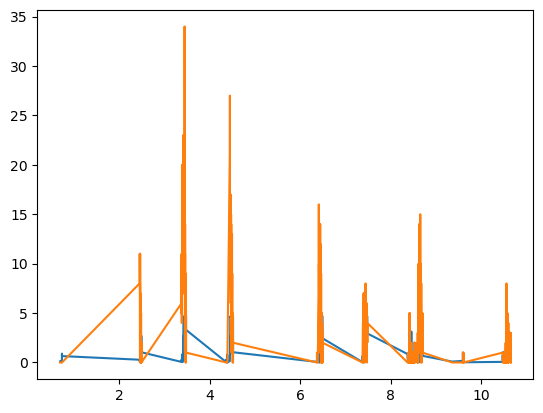

In [32]:
plt.plot(inj2_sch['T'], inj2_sch['IR'])
plt.plot(inj2_sch['T'], inj2_sch['SR'])

In [12]:
df_inj1_h= df_inj1.resample('h').mean()
df_inj2_h= df_inj2.resample('h').sum()


<Axes: xlabel='datetime'>

/home/yzzhang/.local/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 26376 (\N{CJK UNIFIED IDEOGRAPH-6708}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/yzzhang/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26376 (\N{CJK UNIFIED IDEOGRAPH-6708}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


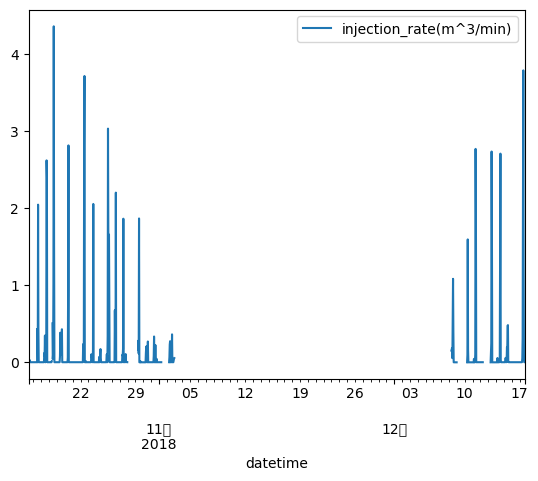

In [20]:
df_inj1_h.plot()

In [23]:
# 找到最后一个注入量非0的时间（以 df_inj2_h 为例）
nonzero = df_inj2_h[df_inj2_h.iloc[:, 0] != 0]
if nonzero.empty:
    last_nonzero_date = None
    print("没有非0注入量的记录")
else:
    last_nonzero_date = nonzero.index.max()
    print(last_nonzero_date)

2019-08-23 15:00:00
